### Dataset => Project Gutenbery 

In [1]:
import re, requests

def fetch_gutenberg_text(book_id: int):
    url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"
    raw = requests.get(url).text

    start = raw.find("*** START OF THE PROJECT GUTENBERG EBOOK")
    end   = raw.find("*** END OF THE PROJECT GUTENBERG EBOOK")
    return raw[start:end] if start != -1 and end != -1 else raw

book_ids = [11, 1342, 84, 1661]  
# 11: Alice, 1342: Pride & Prejudice, 84: Frankenstein, 1661: Sherlock Holmes

texts = [fetch_gutenberg_text(i) for i in book_ids]
text = "\n\n".join(texts)

print("Total characters:", len(text))
print(text[:1000])


Total characters: 1892441
*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice


In [2]:
def tokenize(s:str):
    
    #lower case
    s=s.lower()

    #word or punctuation as tokens
    return re.findall(r"[a-z]+(?:'[a-z]+)?|[0-9]+|[^\w\s]", s)

tokens=tokenize(text)
print(tokens[:50]),len(tokens)




['*', '*', '*', 'start', 'of', 'the', 'project', 'gutenberg', 'ebook', "alice's", 'adventures', 'in', 'wonderland', '*', '*', '*', '[', 'illustration', ']', 'alice', '’', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '3', '.', '0', 'contents', 'chapter', 'i', '.', 'down', 'the', 'rabbit', '-', 'hole', 'chapter', 'ii', '.', 'the', 'pool', 'of']


(None, 404710)

### Build  own vocab + numericalize

In [3]:
from collections import Counter

specials = ["<pad>", "<unk>"]
""" 
<pad> => Used to pad sequences to the same length
<unk> => Used for unknown tokens (mainly for safety)
"""

counter = Counter(tokens)
"""
Example:
["i", "love", "nlp", "i", "love", "python"]
Counter → {"i": 2, "love": 2, "nlp": 1, "python": 1}
"""

# use ALL tokens (no vocab size limit)
vocab_tokens = list(counter.keys())

itos = specials + vocab_tokens
"""
itos = index → string
["<pad>", "<unk>", "i", "love", "nlp", "python", ...]
"""

stoi = {w: i for i, w in enumerate(itos)}
"""
stoi = string → index
{
  "<pad>": 0,
  "<unk>": 1,
  "i": 2,
  "love": 3,
  ...
}
"""

PAD = stoi["<pad>"]
UNK = stoi["<unk>"]

def encode(tok_list):
    return [stoi.get(t, UNK) for t in tok_list]

def decode(id_list):
    return " ".join(itos[i] for i in id_list)

ids = encode(tokens)
print("vocab size:", len(itos))
print(ids[:30])


vocab size: 13958
[2, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 2, 2, 2, 13, 14, 15, 16, 17, 18, 10, 11, 12, 19, 20, 21, 5, 22]


### Batch loader

In [4]:
import torch

data = torch.tensor(ids, dtype=torch.long)

# train/val split
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]


In [5]:
def get_batch(data_1d, batch_size, seq_len, device):
    # random starting positions
    ix = torch.randint(0, len(data_1d) - seq_len - 1, (batch_size,))
    x = torch.stack([data_1d[i:i+seq_len] for i in ix])
    y = torch.stack([data_1d[i+1:i+seq_len+1] for i in ix])
    return x.to(device), y.to(device)


In [6]:
import torch.nn.functional as F

@torch.no_grad()
def generate(model, prompt, max_new_tokens=50, temperature=1.0, device="cuda"):
    model.eval()
    prompt_tokens = tokenize(prompt)
    idx = torch.tensor(encode(prompt_tokens), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        logits = model(idx)           # shape: [B, T, V] in many LMs
        next_logits = logits[:, -1, :] / temperature
        probs = F.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)  # [B,1]
        idx = torch.cat([idx, next_id], dim=1)

    out = idx[0].tolist()
    return decode(out)


In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


# Hyperparameters

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab_size = len(itos)


seq_len     = 64
batch_size  = 64
embed_dim   = 256
hidden_dim  = 512
num_layers  = 2
dropout     = 0.3

lr          = 3e-4
max_steps   = 3000
eval_every  = 200
eval_batches= 50
grad_clip   = 1.0

print("device:", device)
print("vocab_size:", vocab_size)


# Loss estimation on train/val

@torch.no_grad()
def estimate_loss(model, train_data, val_data):
    model.eval()
    out = {}
    for split, data_1d in [("train", train_data), ("val", val_data)]:
        losses = []
        for _ in range(eval_batches):
            x, y = get_batch(data_1d, batch_size, seq_len, device)
            logits = model(x)  # [B, T, V]
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
            losses.append(loss.item())
        out[split] = sum(losses) / len(losses)
    model.train()
    return out


device: cuda
vocab_size: 13958


In [8]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.vocab_size = vocab_size

        self.emb = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        nn.init.normal_(self.emb.weight, mean=0.0, std=0.02)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x, hidden=None):
        x = self.emb(x)                 # [B, T, E]
        out, hidden_out = self.lstm(x, hidden)  # out: [B, T, H]
        out = self.drop(out)
        logits = self.fc(out)           # [B, T, V]
        return logits


In [9]:
model = LSTMLanguageModel(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

print(model)

x_dbg, y_dbg = get_batch(train_data, batch_size=2, seq_len=seq_len, device=device)
logits_dbg = model(x_dbg)

print("x shape:", x_dbg.shape)
print("logits shape:", logits_dbg.shape)
print("y shape:", y_dbg.shape)


LSTMLanguageModel(
  (emb): Embedding(13958, 256)
  (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=13958, bias=True)
)
x shape: torch.Size([2, 64])
logits shape: torch.Size([2, 64, 13958])
y shape: torch.Size([2, 64])


In [10]:
import math
import torch
import torch.nn.functional as F

train_loss_hist = []
val_loss_hist = []
train_ppl_hist = []
val_ppl_hist = []
steps_hist = []

for step in range(max_steps):
    x, y = get_batch(train_data, batch_size, seq_len, device)

    logits = model(x)  # [B, T, vocab_size]
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    if grad_clip is not None:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

    optimizer.step()

    if step % eval_every == 0:
        losses = estimate_loss(model, train_data, val_data)

        train_loss = losses["train"]
        val_loss = losses["val"]

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        steps_hist.append(step)

        train_ppl = math.exp(min(train_loss, 20))
        val_ppl = math.exp(min(val_loss, 20))

        train_ppl_hist.append(train_ppl)
        val_ppl_hist.append(val_ppl)

        print(
            f"step {step:5d} | "
            f"train loss {train_loss:.4f} ppl {train_ppl:.2f} | "
            f"val loss {val_loss:.4f} ppl {val_ppl:.2f}"
        )


step     0 | train loss 9.5382 ppl 13879.46 | val loss 9.5380 ppl 13876.97
step   200 | train loss 6.2985 ppl 543.77 | val loss 6.3621 ppl 579.44
step   400 | train loss 6.2775 ppl 532.46 | val loss 6.3643 ppl 580.74
step   600 | train loss 6.1165 ppl 453.29 | val loss 6.2134 ppl 499.40
step   800 | train loss 5.9752 ppl 393.53 | val loss 6.1084 ppl 449.62
step  1000 | train loss 5.8468 ppl 346.12 | val loss 5.9898 ppl 399.34
step  1200 | train loss 5.6989 ppl 298.54 | val loss 5.8472 ppl 346.28
step  1400 | train loss 5.5765 ppl 264.13 | val loss 5.7565 ppl 316.24
step  1600 | train loss 5.4767 ppl 239.06 | val loss 5.6706 ppl 290.20
step  1800 | train loss 5.4061 ppl 222.76 | val loss 5.6550 ppl 285.73
step  2000 | train loss 5.3486 ppl 210.32 | val loss 5.6004 ppl 270.54
step  2200 | train loss 5.3013 ppl 200.61 | val loss 5.5778 ppl 264.49
step  2400 | train loss 5.2485 ppl 190.29 | val loss 5.5503 ppl 257.31
step  2600 | train loss 5.2026 ppl 181.75 | val loss 5.5200 ppl 249.64
st

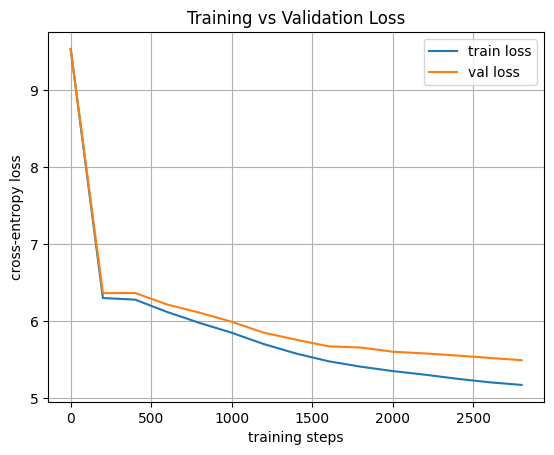

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(steps_hist, train_loss_hist, label="train loss")
plt.plot(steps_hist, val_loss_hist, label="val loss")
plt.xlabel("training steps")
plt.ylabel("cross-entropy loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


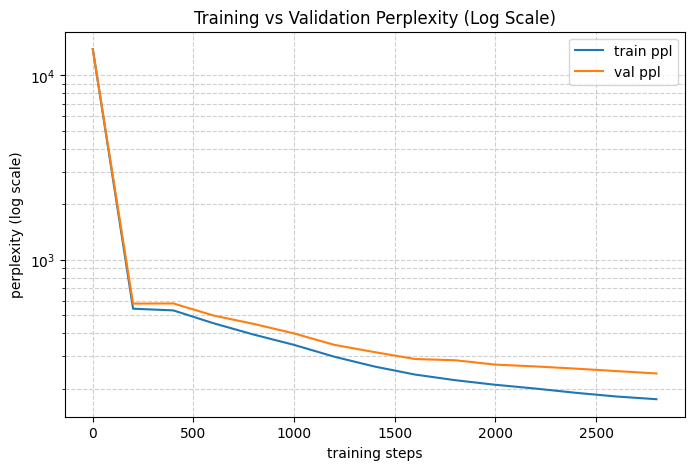

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(steps_hist, train_ppl_hist, label="train ppl")
plt.plot(steps_hist, val_ppl_hist, label="val ppl")

plt.yscale("log")  

plt.xlabel("training steps")
plt.ylabel("perplexity (log scale)")
plt.title("Training vs Validation Perplexity (Log Scale)")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.show()


In [13]:
import os
import torch

save_dir = "code\saved_lstm_lm"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "model.pt")
vocab_path = os.path.join(save_dir, "vocab.pt")

torch.save(model.state_dict(), model_path)
torch.save({"itos": itos, "stoi": stoi}, vocab_path)

print("Saved model to:", model_path)
print("Saved vocab to:", vocab_path)


Saved model to: code\saved_lstm_lm\model.pt
Saved vocab to: code\saved_lstm_lm\vocab.pt


In [14]:
import torch.nn.functional as F
import torch

@torch.no_grad()
def generate_text(model, prompt, max_new_tokens=50, temperature=1.0, device=None):
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    prompt_tokens = tokenize(prompt)
    idx = torch.tensor(encode(prompt_tokens), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        logits = model(idx)                       # [1, T, V]
        next_logits = logits[:, -1, :] / max(temperature, 1e-6)
        probs = F.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)  # [1, 1]
        idx = torch.cat([idx, next_id], dim=1)

    out_ids = idx[0].tolist()
    return decode(out_ids)

print(generate_text(model, "alice was", max_new_tokens=60, temperature=1.0))


alice was his love with so i came . bingley should be near forms . innocent — it went to nothing . i will his side up up . a life should hatred definite to never placed , and come as in present books . i was to expected whom i did acquainted up them amazed very — she must allowed her


In [15]:
model2 = LSTMLanguageModel(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
).to(device)

ckpt = torch.load(model_path, map_location=device)
model2.load_state_dict(ckpt)

vocab = torch.load(vocab_path)
itos2 = vocab["itos"]
stoi2 = vocab["stoi"]

itos = itos2
stoi = stoi2
PAD = stoi["<pad>"]
UNK = stoi["<unk>"]

print(generate_text(model2, "once upon a time", max_new_tokens=200, temperature=0.8))


once upon a time . i see her ! ” “ i is away to the idea of what you could easily be the little cloud to a diggings as his own a town and any opportunity of course to his lips , and it ! he was that the little , it is whatever , and you had been so a blood of her tart , for my arms of a best - good , which secluded the handsome room , for one promising , and she had saved that i seemed not to be betrayed to five street , ” we “ the long soup ’ ” i never , ” “ you , i must be all or him , ” “ they am , though * he be , and he was london — ” said i should really dropped to revenge : “ well , ” “ he is a beautiful house , you and looked in the weapon - - the strength of the more cheeks , and that i am a borne of the jury and which i very street at the violent which the mock fashioned mole , and perceived in a integrity of the most


In [16]:
import os

os.makedirs("code/templates", exist_ok=True)
os.makedirs("code/saved_lstm_lm", exist_ok=True)

print("Folders created:")
print("code/")
print("code/templates/")
print("code/saved_lstm_lm/")


Folders created:
code/
code/templates/
code/saved_lstm_lm/


In [17]:
app_py = r'''
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from flask import Flask, render_template, request

app = Flask(__name__)

def tokenize(s: str):
    s = s.lower()
    return re.findall(r"[a-z]+(?:'[a-z]+)?|[0-9]+|[^\w\s]", s)

class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.emb(x)
        out, hidden = self.lstm(x, hidden)
        out = self.drop(out)
        logits = self.fc(out)
        return logits

def sample_next_token(probs, top_k=50, top_p=0.9):
    probs = probs.squeeze(0)

    if top_k is not None and top_k > 0:
        k = min(top_k, probs.numel())
        v, ix = torch.topk(probs, k)
        mask = torch.zeros_like(probs)
        mask[ix] = probs[ix]
        probs = mask / (mask.sum() + 1e-12)

    if top_p is not None and 0 < top_p < 1:
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumulative = torch.cumsum(sorted_probs, dim=0)
        cutoff = cumulative > top_p
        cutoff[0] = False
        sorted_probs[cutoff] = 0
        probs = torch.zeros_like(probs)
        probs[sorted_idx] = sorted_probs
        probs = probs / (probs.sum() + 1e-12)

    return torch.multinomial(probs, 1).item()

@torch.no_grad()
def generate_text(model, prompt, stoi, itos, max_new_tokens, temperature, top_k, top_p, device):
    model.eval()
    tokens = tokenize(prompt)
    unk = stoi.get("<unk>", 1)

    ids = [stoi.get(t, unk) for t in tokens]
    if len(ids) == 0:
        ids = [unk]

    idx = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        logits = model(idx)
        next_logits = logits[:, -1, :] / max(temperature, 1e-6)
        probs = F.softmax(next_logits, dim=-1)
        next_id = sample_next_token(probs, top_k=top_k, top_p=top_p)
        idx = torch.cat([idx, torch.tensor([[next_id]], device=device)], dim=1)

    return " ".join(itos[i] for i in idx[0].tolist())

device = "cuda" if torch.cuda.is_available() else "cpu"

vocab = torch.load("code/saved_lstm_lm/vocab.pt", map_location="cpu")
itos = vocab["itos"]
stoi = vocab["stoi"]

vocab_size = len(itos)

embed_dim = 256
hidden_dim = 512
num_layers = 2
dropout = 0.2

model = LSTMLanguageModel(vocab_size, embed_dim, hidden_dim, num_layers, dropout).to(device)
model.load_state_dict(torch.load("code/saved_lstm_lm/model.pt", map_location=device))
model.eval()

@app.route("/", methods=["GET", "POST"])
def index():
    output = ""
    prompt = "once upon a time"
    max_new_tokens = 80
    temperature = 0.8
    top_k = 50
    top_p = 0.9

    if request.method == "POST":
        prompt = request.form["prompt"]
        max_new_tokens = int(request.form["max_new_tokens"])
        temperature = float(request.form["temperature"])
        top_k = int(request.form["top_k"])
        top_p = float(request.form["top_p"])

        output = generate_text(
            model, prompt, stoi, itos,
            max_new_tokens, temperature, top_k, top_p, device
        )

    return render_template(
        "index.html",
        output=output,
        prompt=prompt,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
    )

if __name__ == "__main__":
    app.run(debug=True)
'''
with open("code/app.py", "w", encoding="utf-8") as f:
    f.write(app_py)

print("code/app.py written successfully")


code/app.py written successfully


In [18]:
html = r'''
<!doctype html>
<html>
<head>
  <meta charset="utf-8">
  <title>LSTM Language Model</title>
  <style>
    body { font-family: Arial; max-width: 900px; margin: 30px; }
    textarea { width: 100%; height: 120px; }
    .row { display: flex; gap: 12px; margin-top: 10px; flex-wrap: wrap; }
    .box { display: flex; flex-direction: column; min-width: 180px; }
    input { padding: 6px; }
    button { padding: 10px 16px; margin-top: 12px; }
    pre { background: #f4f4f4; padding: 12px; white-space: pre-wrap; }
  </style>
</head>
<body>
  <h2>LSTM Gutenberg Text Generator</h2>

  <form method="POST">
    <label>Prompt</label>
    <textarea name="prompt">{{ prompt }}</textarea>

    <div class="row">
      <div class="box">
        <label>Max tokens</label>
        <input type="number" name="max_new_tokens" value="{{ max_new_tokens }}">
      </div>
      <div class="box">
        <label>Temperature</label>
        <input type="number" step="0.05" name="temperature" value="{{ temperature }}">
      </div>
      <div class="box">
        <label>Top-k</label>
        <input type="number" name="top_k" value="{{ top_k }}">
      </div>
      <div class="box">
        <label>Top-p</label>
        <input type="number" step="0.05" name="top_p" value="{{ top_p }}">
      </div>
    </div>

    <button type="submit">Generate</button>
  </form>

  {% if output %}
    <h3>Generated Text</h3>
    <pre>{{ output }}</pre>
  {% endif %}
</body>
</html>
'''
with open("code/templates/index.html", "w", encoding="utf-8") as f:
    f.write(html)

print("code/templates/index.html written successfully")


code/templates/index.html written successfully
